# Auto-commission and tune, end to end

The day a real motor turns, this notebook is the procedure: characterise
the AFE, the inverter and the motor off the board's own converters, put
every measured constant into the calibration record (device 3, ids
15..44), search a robust controller for exactly that machine with the
firmware's own compiled control law, write it, and let the drive verify
itself. The firmware reloads the record on every mode change - nothing
below flashes anything.

Against the stand-in today (`SIMULATED = True`), whose motor has known
constants to recover - so every step can be judged. At the bench: flip
`SIMULATED`, set the port, and `ARM = True` once the stage may switch.
Nothing here is a measurement until it runs there (invariant 10).

In [1]:
import math
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

root = Path.cwd()
while not (root / 'host' / 'coaxial').is_dir():
    root = root.parent
sys.path.insert(0, str(root / 'host'))
sys.path.insert(0, str(root / 'host' / 'tools'))

from coaxial import Coaxial63100
from coaxial.commission import Commissioning
from coaxial.motor import BENCH_MOTOR
import montecarlo as mc

SIMULATED = True                   # the stand-in; False at the bench
PORT = 'COM4'                      # first guess - open_session probes
ARM = True                         # let steps set MOE (stand-in: harmless)
I_H_MAX = 1.0                      # HF current ceiling, A
I_MAX, I_TRIP = 5.0, 8.0           # this machine's, not the board's 100 A
K_PROP = 2.8e-6                    # the load the tuning pulls against
RATED_RPM = 3000.0

BLUE, RED, GREY = '#1f4e79', '#c0392b', '#95a5a6'
plt.rcParams.update({
    'figure.dpi': 120, 'axes.spines.top': False,
    'axes.spines.right': False, 'axes.grid': True, 'grid.alpha': 0.15})

rig = Coaxial63100(port=PORT, simulated_device=SIMULATED,
                   power_afe=True).open()
arm = dict(bypass_sto=True, ignore_interlock=True) if ARM else None
c = Commissioning(rig, arm=arm, log=lambda *a: None, i_h_max=I_H_MAX,
                  rated_rpm=RATED_RPM)
supply = c.gate_supply()
print(rig)
print('fs %.0f Hz, gate supply %.2f V -> %s' % (
    c.fs, supply['volts'] or 0.0,
    'powered' if supply['powered'] else 'UNPOWERED: switching steps run dry'))

<Coaxial63100 Simulated SIMULATED>
fs 50000 Hz, gate supply 0.37 V -> UNPOWERED: switching steps run dry


## The AFE

Noise floor and ENOB per phase, the sample point moved to where the
switching pickup is least, every channel tared - except one: **Phase V's
offset is broken silicon on the reference board and is flagged, not
zeroed** (HARDWARE.md). Zeroing is for a channel's own offset. Then the
gain mismatch between phases and the shunt's sign.

Phase U offset  +1400 tared
Phase V offset  -8030 SUSPECT - not zeroed
Phase W offset   +360 tared
gain mismatch 1.50 %, sign +1


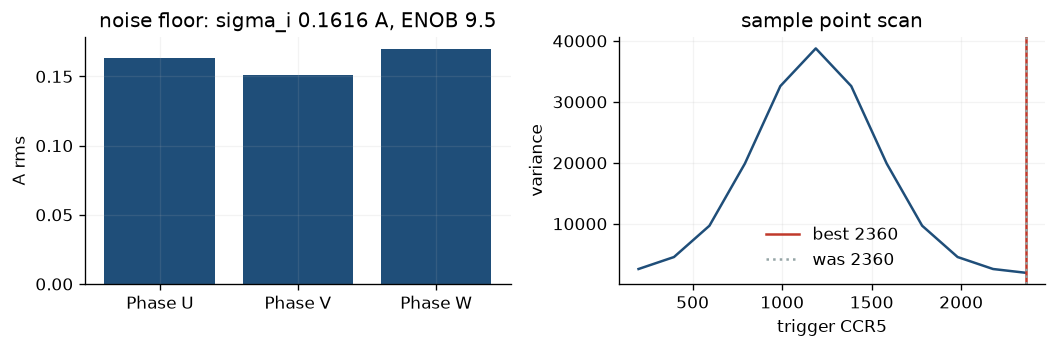

In [2]:
afe = c.afe_noise(zero_vector=ARM)
scan = c.sample_point_scan()
off = c.offsets()
gm = c.gain_mismatch()
sign = c.sign_check()

fig, ax = plt.subplots(1, 2, figsize=(9, 3))
rows = afe.get('zero_vector') or afe['gates_off']
names = [n for n in rows if n.startswith('Phase')]
ax[0].bar(names, [rows[n]['sd_amps'] for n in names], color=BLUE)
ax[0].set(title='noise floor: sigma_i %.4f A, ENOB %.1f'
          % (afe['sigma_i'], afe['enob']), ylabel='A rms')
t = [row['trigger'] for row in scan['table']]
ax[1].plot(t, [row['variance'] for row in scan['table']], color=BLUE)
ax[1].axvline(scan['best'], color=RED, label='best %d' % scan['best'])
ax[1].axvline(scan['was'], color=GREY, ls=':', label='was %d' % scan['was'])
ax[1].set(title='sample point scan', xlabel='trigger CCR5', ylabel='variance')
ax[1].legend(frameon=False)
fig.tight_layout()

for n, row in off.items():
    print('%s offset %+6d %s' % (n, row['offset_raw'],
                                 'SUSPECT - not zeroed' if row['suspect'] else 'tared'))
print('gain mismatch %.2f %%, sign %+d'
      % (gm.get('mismatch_pct', float('nan')), sign.get('sign', 0)))

## The inverter, then the motor

`deadtime` holds a d current and reads vd back: R from the slope, the
dead-time voltage from what is left - unfolded into the board's
compensation table and written. `l_map` sweeps the injection's angle for
L(phi) - the saliency the observer lives on - and `flux` spins I/f and
reads lambda out of the back-EMF. **Each result lands in the record as it
is measured**; the next step already computes with it.

,r,ld,lq,lambda
recovered,0.051415,0.00002,0.000029,0.005462
stand-in truth,0.050000,0.00002,0.000030,0.005000


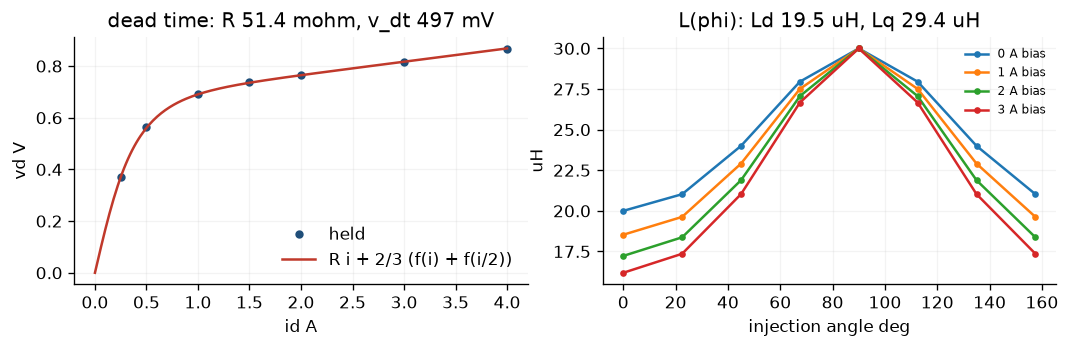

In [3]:
dt = c.deadtime()
lm = c.l_map()
fx = c.flux()

fig, ax = plt.subplots(1, 2, figsize=(9, 3))
pts = np.array(dt['points'])
ax[0].plot(pts[:, 0], pts[:, 1], 'o', color=BLUE, ms=4, label='held')
ii = np.linspace(0.0, pts[:, 0].max(), 200)
f = lambda i: dt['v_dt'] * np.tanh(i / dt['i_knee'])
ax[0].plot(ii, dt['r'] * ii + (2.0 / 3.0) * (f(ii) + f(ii / 2.0)),
           color=RED, label='R i + 2/3 (f(i) + f(i/2))')
ax[0].set(title='dead time: R %.1f mohm, v_dt %.0f mV'
          % (1e3 * dt['r'], 1e3 * dt['v_dt']), xlabel='id A', ylabel='vd V')
ax[0].legend(frameon=False)
for bias, row in lm['rows'].items():
    if row.get('measured'):
        ax[1].plot(np.degrees(lm['angles']), 1e6 * np.array(row['l']),
                   marker='o', ms=3, label='%.0f A bias' % bias)
ax[1].set(title='L(phi): Ld %.1f uH, Lq %.1f uH'
          % (1e6 * lm['ld'], 1e6 * lm['lq']),
          xlabel='injection angle deg', ylabel='uH')
ax[1].legend(frameon=False, fontsize=7)
fig.tight_layout()

known = c._known()
truth = {'r': BENCH_MOTOR.r, 'ld': BENCH_MOTOR.ld, 'lq': BENCH_MOTOR.lq,
         'lambda': BENCH_MOTOR.lam} if SIMULATED else {}
pd.DataFrame({'recovered': {k: known[k] for k in ('r', 'ld', 'lq', 'lambda')},
              **({'stand-in truth': truth} if truth else {})}).T

## The tuning: arithmetic first, then the search

`gains()` is the closed-form design - current loop from R and L, Kalman
gains from the measured noise, the blend from the crossover - and writes
it. Then the Monte Carlo takes over: the firmware's compiled control law
against plants drawn AROUND what was just measured (copper hot, L a
quarter off, the dead time misjudged), at the link this board actually
reads, sized to this machine's limits. The candidate that is only good
when the estimates are right loses to the one that holds when they are
not. Its winner goes into the record.

In [4]:
before = c.drive.params()
c.budget()
analytic = c.gains()
decision = c.decide()
print('analytic: iloop %.0f Hz, PLL %.0f Hz, crossover %.0f rpm - %s'
      % (analytic['loop']['bw_hz'],
         (analytic['kalman'] or {}).get('wn_hz', 0.0),
         analytic['crossover']['rpm'], decision['method']))

vdc = float(c.drive.state()['vdc'])
motor = {'name': 'identified', 'r': known['r'], 'ld': known['ld'],
         'lq': known['lq'], 'lam': known['lambda'],
         'poles': int(known['pole_pairs']),
         'sat': 0.3, 'i_sat': 2.0 * known['i_max']}
extra = {'motor': motor, 'i_max': I_MAX, 'i_trip': I_TRIP,
         'i_h_max': I_H_MAX, 'k_prop': K_PROP}
def sweep_over(pool, knob_sets, seed0):
    jobs = [dict(vdc=vdc, knobs=k, seed=1000 * (seed0 + i) + s, **extra)
            for i, k in enumerate(knob_sets) for s in range(8)]
    return mc.sweep(pool, jobs, progress=False)

t0 = time.perf_counter()
with mc.pool() as p:
    wide = sweep_over(p, mc.candidates(12, seed=2), 0)
    lead = mc.score(wide).nsmallest(1, 'robust').iloc[0]
    box = mc.around({k: float(lead[k]) for k in mc.KNOBS})
    fine = sweep_over(p, mc.candidates(8, seed=9, box=box), 100)
win = mc.score(fine).nsmallest(1, 'robust').iloc[0]
knobs = {k: float(win[k]) for k in mc.KNOBS}
print('%d + %d runs in %.0f s at %.1f V' % (len(wide), len(fine),
                                            time.perf_counter() - t0, vdc))
print('hypercube best mean %.3f -> refined mean %.3f, p90 %.3f, trips %d of %d'
      % (lead['mean'], win['mean'], win['p90'], int(fine.trip.sum()), len(fine)))

params = mc.design(knobs, float(vdc), mc.Parameters(**motor),
                   I_MAX, I_TRIP, I_H_MAX)
WRITE = {'kp': 'drv_kp_mv_per_a', 'ki': 'drv_ki_v_per_as',
         'l1': 'drv_l1_milli', 'l2': 'drv_l2_milli',
         'inj_volts': 'drv_inj_mv', 'inj_periods': 'drv_inj_periods',
         'eps_gain': 'drv_eps_gain_ua_per_rad',
         'w_lo': 'drv_w_lo_mrad_s', 'w_hi': 'drv_w_hi_mrad_s'}
c.drive.set_params(**{rec: params[k] for k, rec in WRITE.items()})
after = c.drive.params()
names = sorted(n for n in after if before.get(n) != after[n])
pd.DataFrame({'before': [before.get(n) for n in names],
              'after': [after[n] for n in names]}, index=names)

analytic: iloop 2500 Hz, PLL 71 Hz, crossover 94 rpm - injection


96 + 64 runs in 3 s at 24.8 V
hypercube best mean 1.424 -> refined mean 0.089, p90 0.103, trips 37 of 64


,before,after
drv_eps_gain_ua_per_rad,0.0,0.500428
drv_inj_mv,0.0,1.454846
drv_ki_v_per_as,250.0,208.647954
drv_kp_mv_per_a,0.1,0.079319
drv_l1_milli,0.1,0.028965
drv_l2_milli,100.0,5.538534
drv_sigma_i_ua,0.0,0.161622
drv_w_hi_mrad_s,120.0,463.846518
drv_w_lo_mrad_s,60.0,198.876535


## The drive verifies itself

The polarity pulse settles which end of the d axis carries the magnet,
then a sensorless run under the WRITTEN parameters - the innovation must
be white (Ljung-Box) and its deviation is the angle-error proxy. This is
the drive judging its own tune the way it will at the bench; the numbers
are the stand-in's until then.

polarity: +34.0 / -18.0
zero-speed: yes (SNR 20 dB), min closed-loop 3 %, iloop 2500 Hz, sigma_theta 2.3 deg at 0 %


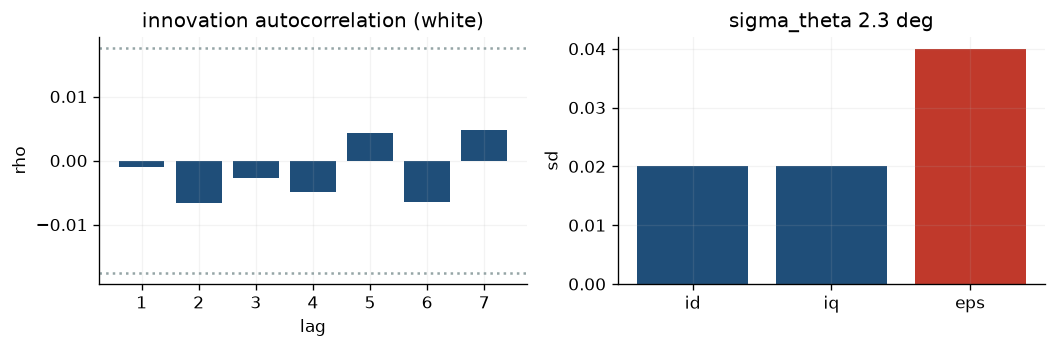

In [5]:
pol = c.polarity()
v = c.verify(iq=0.5, seconds=1.0)
w = v['window']
fig, ax = plt.subplots(1, 2, figsize=(9, 3))
lags = np.arange(1, len(w['rho']) + 1)
ax[0].bar(lags, w['rho'], color=BLUE)
bound = 1.96 / math.sqrt(max(1, w['fields']['eps']['n']))
ax[0].axhline(bound, color=GREY, ls=':')
ax[0].axhline(-bound, color=GREY, ls=':')
ax[0].set(title='innovation autocorrelation (%s)'
          % ('white' if v['ljung_box']['white'] else 'NOT white'),
          xlabel='lag', ylabel='rho')
f = w['fields']
ax[1].bar(['id', 'iq', 'eps'], [f[k]['sd'] or 0.0 for k in ('id', 'iq', 'eps')],
          color=(BLUE, BLUE, RED))
ax[1].set(title='sigma_theta %.1f deg' % v['sigma_theta_deg'], ylabel='sd')
fig.tight_layout()
print('polarity: +%.1f / -%.1f%s' % (pol['pol_pos'], pol['pol_neg'],
                                     ', flipped pi' if pol['flipped'] else ''))
print(c.report()['line'])
rig.close()

## The bench day

`SIMULATED = False`, the port, `ARM = True` once the stage may switch -
and the same cells run in the same order. What changes is only what the
numbers mean: the record then holds measurements, `sat`/`i_sat` above
stop being placeholders the moment a saturation map exists, and
`board.calibration.save()` keeps the tune across a reset. The board never
judges any of it - it reports, refuses what it must, and drops MOE at its
ceilings (invariant 10); pass and fail live here, beside the numbers that
decided them.